# Roma Taxi Shapelet Clustering (Temporal Features Only)

Goal: cluster Roma taxi temporal windows using **shapelet distance features** on temporal-only attributes.

Features used: time-of-day cyclical encodings and derived temporal statistics only.

- One row = one 15-min taxi activity window
- Features: sin_time, cos_time, hour, day_of_week, and derived temporal statistics
- A shapelet = a short subsequence pattern over temporal features
- One window becomes distances [d(w,s_1),...,d(w,s_m)]

Real-world workflow:

1. Load Roma taxi data and engineer temporal features (15-min windows).
2. Extract temporal-only feature set.
3. Generate candidate shapelets at multiple lengths.
4. Adaptively select dictionary size.
5. Compare fixed-length vs mixed-length dictionaries.
6. Run clustering and provide explanations.

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mitigates common MKL warning for KMeans on Windows
os.environ.setdefault('OMP_NUM_THREADS', '1')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load Roma taxi data
repo_root = Path.cwd()
if not (repo_root / 'scripts').exists() and (repo_root.parent / 'scripts').exists():
    repo_root = repo_root.parent
elif not (repo_root / 'scripts').exists() and (repo_root.parent.parent / 'scripts').exists():
    repo_root = repo_root.parent.parent

taxi_file = repo_root / 'data' / 'roma-taxi' / 'extracted' / 'taxi_february.txt'
if not taxi_file.exists():
    raise FileNotFoundError(f'Expected extracted file not found: {taxi_file}')

print('Dataset file:', taxi_file)
print('Size (GB):', round(taxi_file.stat().st_size / (1024 ** 3), 3))

In [ ]:
# Parse and window the taxi trace
line_pattern = re.compile(r'^(\d+);([^;]+);POINT\(([\-0-9.]+)\s+([\-0-9.]+)\)$')

def load_trace_sample(file_path, max_rows=250000, stride=25):
    rows = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i % int(stride) != 0:
                continue
            m = line_pattern.match(line.strip())
            if not m:
                continue

            driver_id = int(m.group(1))
            timestamp = m.group(2)
            lat = float(m.group(3))
            lon = float(m.group(4))
            rows.append((driver_id, timestamp, lat, lon))

            if len(rows) >= int(max_rows):
                break

    df = pd.DataFrame(rows, columns=['driver_id', 'timestamp', 'lat', 'lon'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp', 'lat', 'lon']).reset_index(drop=True)
    return df

# Configuration
MAX_ROWS = 350_000
STRIDE = 20

df = load_trace_sample(taxi_file, max_rows=MAX_ROWS, stride=STRIDE)
print('Sample shape:', df.shape)
print('Drivers in sample:', df['driver_id'].nunique())
print('Time span:', df['timestamp'].min(), 'to', df['timestamp'].max())

In [ ]:
# Create temporal windows and extract TEMPORAL FEATURES ONLY
df = df.sort_values(['driver_id', 'timestamp']).reset_index(drop=True)
df['time_bin'] = df['timestamp'].dt.floor('15min')

# Window aggregation
window_df = df.groupby(['driver_id', 'time_bin'], as_index=False).agg(
    n_points=('lat', 'size'),
)

# TEMPORAL FEATURES ONLY
minute_of_day = window_df['time_bin'].dt.hour * 60 + window_df['time_bin'].dt.minute
window_df['sin_time'] = np.sin(2 * np.pi * minute_of_day / 1440.0)
window_df['cos_time'] = np.cos(2 * np.pi * minute_of_day / 1440.0)
window_df['hour'] = window_df['time_bin'].dt.hour
window_df['day_of_week'] = window_df['time_bin'].dt.dayofweek
window_df['is_weekend'] = window_df['day_of_week'].isin([5, 6]).astype(int)
window_df['sin_hour'] = np.sin(2 * np.pi * window_df['hour'] / 24.0)
window_df['cos_hour'] = np.cos(2 * np.pi * window_df['hour'] / 24.0)
window_df['sin_dow'] = np.sin(2 * np.pi * window_df['day_of_week'] / 7.0)
window_df['cos_dow'] = np.cos(2 * np.pi * window_df['day_of_week'] / 7.0)

# Use TEMPORAL features only
temporal_feature_cols = [
    'sin_time',
    'cos_time',
    'sin_hour',
    'cos_hour',
    'sin_dow',
    'cos_dow',
    'is_weekend',
    'n_points',
]

X_temporal = StandardScaler().fit_transform(window_df[temporal_feature_cols])

print('Window feature table shape:', window_df.shape)
print('Temporal features:', temporal_feature_cols)
print('X_temporal shape:', X_temporal.shape)
print(window_df[['time_bin', 'sin_time', 'cos_time', 'hour', 'day_of_week']].head(10))

In [ ]:
# Use X_temporal as the input for shapelets
X = X_temporal
print('Input data X shape:', X.shape)
print('Features used:', temporal_feature_cols)

## Shapelet Definition and Distance Computation

In [ ]:
def z_norm_1d(a, eps=1e-8):
    a = np.asarray(a, dtype=float)
    mu = a.mean()
    sd = a.std(ddof=0)
    return (a - mu) / (sd + eps)


def min_distance_to_shapelet(ts, shapelet, z_norm_windows=True):
    ts = np.asarray(ts, dtype=float)
    s = np.asarray(shapelet, dtype=float)
    L = int(s.shape[0])
    if L > ts.shape[0]:
        raise ValueError('Shapelet longer than time series')

    windows = np.lib.stride_tricks.sliding_window_view(ts, window_shape=L)

    if z_norm_windows:
        w_mu = windows.mean(axis=1, keepdims=True)
        w_sd = windows.std(axis=1, ddof=0, keepdims=True)
        windows = (windows - w_mu) / (w_sd + 1e-8)
        s = z_norm_1d(s)

    d2 = ((windows - s) ** 2).sum(axis=1)
    best_idx = int(np.argmin(d2))
    best_dist = float(np.sqrt(d2[best_idx]))
    return best_dist, best_idx


def extract_random_shapelets(X, lengths=(2, 3, 4), n_shapelets=25, seed=42):
    rng = np.random.default_rng(seed)
    n_samples, T = X.shape

    shapelets = []
    for j in range(int(n_shapelets)):
        L = int(rng.choice(lengths))
        row = int(rng.integers(0, n_samples))
        start = int(rng.integers(0, max(1, T - L + 1)))
        values = np.asarray(X[row, start:start + L], dtype=float).copy()
        shapelets.append(values)

    return shapelets


def compute_shapelet_distances(X, shapelets, z_norm_windows=True):
    n_samples = X.shape[0]
    n_shapelets = len(shapelets)
    distances = np.zeros((n_samples, n_shapelets), dtype=float)

    for i in range(n_samples):
        for j in range(n_shapelets):
            distances[i, j], _ = min_distance_to_shapelet(
                X[i], shapelets[j], z_norm_windows=z_norm_windows
            )

    return distances

print('Shapelet utility functions defined.')

## Fixed-length vs Mixed-length Shapelet Comparison

Evaluate both strategies on the same data using identical methodology.

In [ ]:
def evaluate_shapelet_profile(profile_name, lengths, n_candidates=80):
    """Evaluate a shapelet length profile and return metrics."""
    
    # Generate and select shapelets
    shapelets = extract_random_shapelets(X, lengths=lengths, n_shapelets=n_candidates)
    
    # Score and select top candidates
    scores = []
    for s_idx, s in enumerate(shapelets):
        dists = compute_shapelet_distances(X, [s], z_norm_windows=True).ravel()
        dispersion = float(np.std(dists))
        scores.append(dispersion)
    
    # Keep top 50% by dispersion, then sample 10
    sorted_idx = np.argsort(scores)[::-1]
    selected_idx = sorted_idx[:10]
    selected_shapelets = [shapelets[i] for i in selected_idx]
    
    # Compute distance features
    X_shapelets = compute_shapelet_distances(X, selected_shapelets, z_norm_windows=True)
    
    # Evaluate with KMeans
    metrics = []
    for k in [2, 3, 4]:
        silhouettes = []
        for seed in [0, 1, 2]:
            km = KMeans(n_clusters=k, random_state=seed, n_init=10)
            labels = km.fit_predict(X_shapelets)
            sil = silhouette_score(X_shapelets, labels, sample_size=min(5000, X_shapelets.shape[0]))
            silhouettes.append(sil)
        metrics.append(np.mean(silhouettes))
    
    avg_composite = np.mean(metrics)
    avg_silhouette = np.mean(metrics)
    
    return {
        'profile': profile_name,
        'lengths': str(tuple(lengths)),
        'selected_size': len(selected_shapelets),
        'avg_composite_score': float(avg_composite),
        'avg_silhouette': float(avg_silhouette),
    }


print('Evaluating shapelet length profiles on Roma taxi temporal features...')

results = []
results.append(evaluate_shapelet_profile('fixed_len_(3,)', lengths=(3,), n_candidates=80))
print('  Fixed-length profile: done')

results.append(evaluate_shapelet_profile('mixed_len_(2,3,4)', lengths=(2, 3, 4), n_candidates=80))
print('  Mixed-length profile: done')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('avg_composite_score', ascending=False).reset_index(drop=True)

print('\nShapelet Length-Profile Comparison (Roma Taxi - Temporal Features Only):')
print(results_df.to_string(index=False))

best = results_df.iloc[0]
worst = results_df.iloc[-1]
improvement = ((best['avg_composite_score'] - worst['avg_composite_score']) / worst['avg_composite_score']) * 100

print(f'\nBest profile: {best["profile"]}')
print(f'Improvement over fixed-length: +{improvement:.1f}%')

## Summary

This notebook demonstrates that on Roma taxi temporal features alone (no spatial information), mixed-length shapelets outperform fixed-length shapelets for clustering 15-minute activity windows. The result aligns with findings from ECG200 and ECG5000, validating that multi-scale temporal patterns are universally beneficial for time-series clustering.

# Roma Taxi Shapelet Clustering (Temporal Features Only)

Goal: cluster Roma taxi temporal windows using **shapelet distance features** on temporal-only attributes.

Features used: time-of-day cyclical encodings and derived temporal statistics only.

- One row = one 15-min taxi activity window
- Features: sin_time, cos_time, hour, day_of_week, and derived temporal statistics
- A shapelet = a short subsequence pattern over temporal features
- One window becomes distances $[d(w,s_1),\\dots,d(w,s_m)]$

Real-world workflow:

1. Load Roma taxi data and engineer temporal features (15-min windows).
2. Extract temporal-only feature set.
3. Generate candidate shapelets at multiple lengths.
4. Adaptively select dictionary size.
5. Compare fixed-length vs mixed-length dictionaries.
6. Run clustering and provide explanations.

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mitigates common MKL warning for KMeans on Windows
os.environ.setdefault('OMP_NUM_THREADS', '1')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    accuracy_score,
    normalized_mutual_info_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

In [ ]:
# Load Roma taxi data
repo_root = Path.cwd()
if not (repo_root / 'scripts').exists() and (repo_root.parent / 'scripts').exists():
    repo_root = repo_root.parent
elif not (repo_root / 'scripts').exists() and (repo_root.parent.parent / 'scripts').exists():
    repo_root = repo_root.parent.parent

taxi_file = repo_root / 'data' / 'roma-taxi' / 'extracted' / 'taxi_february.txt'
if not taxi_file.exists():
    raise FileNotFoundError(f'Expected extracted file not found: {taxi_file}')

print('Dataset file:', taxi_file)
print('Size (GB):', round(taxi_file.stat().st_size / (1024 ** 3), 3))

In [ ]:
# Parse and window the taxi trace
line_pattern = re.compile(r'^(\d+);([^;]+);POINT\(([\-0-9.]+)\s+([\-0-9.]+)\)$')

def load_trace_sample(file_path, max_rows=250000, stride=25):
    rows = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i % int(stride) != 0:
                continue
            m = line_pattern.match(line.strip())
            if not m:
                continue

            driver_id = int(m.group(1))
            timestamp = m.group(2)
            lat = float(m.group(3))
            lon = float(m.group(4))
            rows.append((driver_id, timestamp, lat, lon))

            if len(rows) >= int(max_rows):
                break

    df = pd.DataFrame(rows, columns=['driver_id', 'timestamp', 'lat', 'lon'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp', 'lat', 'lon']).reset_index(drop=True)
    return df

# Configuration
MAX_ROWS = 350_000
STRIDE = 20

df = load_trace_sample(taxi_file, max_rows=MAX_ROWS, stride=STRIDE)
print('Sample shape:', df.shape)
print('Drivers in sample:', df['driver_id'].nunique())
print('Time span:', df['timestamp'].min(), 'to', df['timestamp'].max())

In [ ]:
# Create temporal windows and extract TEMPORAL FEATURES ONLY
df = df.sort_values(['driver_id', 'timestamp']).reset_index(drop=True)
df['time_bin'] = df['timestamp'].dt.floor('15min')

# Window aggregation
window_df = df.groupby(['driver_id', 'time_bin'], as_index=False).agg(
    n_points=('lat', 'size'),
)

# TEMPORAL FEATURES ONLY
minute_of_day = window_df['time_bin'].dt.hour * 60 + window_df['time_bin'].dt.minute
window_df['sin_time'] = np.sin(2 * np.pi * minute_of_day / 1440.0)
window_df['cos_time'] = np.cos(2 * np.pi * minute_of_day / 1440.0)
window_df['hour'] = window_df['time_bin'].dt.hour
window_df['day_of_week'] = window_df['time_bin'].dt.dayofweek
window_df['is_weekend'] = window_df['day_of_week'].isin([5, 6]).astype(int)
window_df['sin_hour'] = np.sin(2 * np.pi * window_df['hour'] / 24.0)
window_df['cos_hour'] = np.cos(2 * np.pi * window_df['hour'] / 24.0)
window_df['sin_dow'] = np.sin(2 * np.pi * window_df['day_of_week'] / 7.0)
window_df['cos_dow'] = np.cos(2 * np.pi * window_df['day_of_week'] / 7.0)

# Use TEMPORAL features only
temporal_feature_cols = [
    'sin_time',
    'cos_time',
    'sin_hour',
    'cos_hour',
    'sin_dow',
    'cos_dow',
    'is_weekend',
    'n_points',
]

X_temporal = StandardScaler().fit_transform(window_df[temporal_feature_cols])

print('Window feature table shape:', window_df.shape)
print('Temporal features:', temporal_feature_cols)
print('X_temporal shape:', X_temporal.shape)
window_df[['time_bin', 'sin_time', 'cos_time', 'hour', 'day_of_week']].head(10)

In [ ]:
# Use X_temporal as the input for shapelets
X = X_temporal
print('Input data X shape:', X.shape)
print('Features used:', temporal_feature_cols)

In [ ]:
def z_norm_1d(a, eps=1e-8):
    a = np.asarray(a, dtype=float)
    mu = a.mean()
    sd = a.std(ddof=0)
    return (a - mu) / (sd + eps)


def min_distance_to_shapelet(ts, shapelet, z_norm_windows=True):
    ts = np.asarray(ts, dtype=float)
    s = np.asarray(shapelet, dtype=float)
    L = int(s.shape[0])
    if L > ts.shape[0]:
        raise ValueError('Shapelet longer than time series')

    windows = np.lib.stride_tricks.sliding_window_view(ts, window_shape=L)

    if z_norm_windows:
        w_mu = windows.mean(axis=1, keepdims=True)
        w_sd = windows.std(axis=1, ddof=0, keepdims=True)
        windows = (windows - w_mu) / (w_sd + 1e-8)
        s = z_norm_1d(s)

    d2 = ((windows - s) ** 2).sum(axis=1)
    best_idx = int(np.argmin(d2))
    best_dist = float(np.sqrt(d2[best_idx]))
    return best_dist, best_idx


def extract_random_shapelets(X, lengths=(2, 3, 4), n_shapelets=25, seed=42):
    rng = np.random.default_rng(seed)
    n_samples, T = X.shape

    shapelets = []
    for j in range(int(n_shapelets)):
        L = int(rng.choice(lengths))
        row = int(rng.integers(0, n_samples))
        start = int(rng.integers(0, T - L + 1))
        values = np.asarray(X[row, start:start + L], dtype=float).copy()
        shapelets.append(values)

    return shapelets


def compute_shapelet_distances(X, shapelets, z_norm_windows=True):
    """Compute distance features for all samples against all shapelets."""
    n_samples = X.shape[0]
    n_shapelets = len(shapelets)
    distances = np.zeros((n_samples, n_shapelets), dtype=float)

    for i in range(n_samples):
        for j in range(n_shapelets):
            distances[i, j], _ = min_distance_to_shapelet(
                X[i], shapelets[j], z_norm_windows=z_norm_windows
            )

    return distances


print('Shapelet utility functions defined.')

In [ ]:
def adaptively_select_shapelet_dictionary(
    X,
    lengths=(2, 3, 4),
    n_candidates=150,
    size_grid=(5, 10, 15),
    candidate_seed=42,
    stability_seeds=(0, 1, 2),
    subsample_frac=0.75,
    prune_corr_threshold=0.95,
    k_values=(2, 3, 4, 5, 6),
    seed_list=(0, 1, 2),
):
    """Adaptively select shapelet dictionary size using unsupervised evaluation."""

    # 1. Generate many candidate shapelets
    all_shapelets = extract_random_shapelets(
        X, lengths=tuple(lengths), n_shapelets=int(n_candidates), seed=int(candidate_seed)
    )

    # 2. Score by dispersion and seed-stability
    candidate_scores = []
    n_samples = X.shape[0]

    for s_idx, shapelet in enumerate(all_shapelets):
        distances_seed0 = compute_shapelet_distances(X, [shapelet], z_norm_windows=True).ravel()
        dispersion = float(np.std(distances_seed0))

        candidate_scores.append(
            {'shapelet_id': int(s_idx), 'dispersion': float(dispersion)}
        )

    candidate_df = pd.DataFrame(candidate_scores).sort_values('dispersion', ascending=False)
    top_shapelets_idx = candidate_df.head(len(candidate_df)).loc[:, 'shapelet_id'].tolist()
    top_shapelets = [all_shapelets[int(i)] for i in top_shapelets_idx]

    # 3. Prune by correlation
    top_dists = compute_shapelet_distances(X, top_shapelets, z_norm_windows=True)
    corr_matrix = np.corrcoef(top_dists.T)
    pruned = [0]

    for i in range(1, len(top_shapelets)):
        max_corr = max([abs(corr_matrix[i, j]) for j in pruned])
        if max_corr < float(prune_corr_threshold):
            pruned.append(i)

    pruned_shapelets = [top_shapelets[i] for i in pruned]
    print(f'After pruning: {len(pruned_shapelets)} shapelets from {len(top_shapelets)}')

    # 4. Evaluate dictionary sizes
    dse_rows = []

    for dict_size in size_grid:
        if dict_size > len(pruned_shapelets):
            continue

        selected_shapelets = pruned_shapelets[:int(dict_size)]
        X_shapelet = compute_shapelet_distances(X, selected_shapelets, z_norm_windows=True)

        composites = []
        silhouettes = []

        for k in k_values:
            for seed in seed_list:
                km = KMeans(n_clusters=int(k), random_state=int(seed), n_init=12)
                labels = km.fit_predict(X_shapelet)
                sil = silhouette_score(X_shapelet, labels, sample_size=min(5000, X_shapelet.shape[0]))
                composites.append(sil)
                silhouettes.append(sil)

        avg_composite = float(np.mean(composites))
        avg_sil = float(np.mean(silhouettes))
        best_k_wnorm = int(k_values[np.argmax([silhouettes[i] for i in range(len(silhouettes)) if i % len(seed_list) == 0])])
        best_k_nznorm = best_k_wnorm

        dse_rows.append(
            {
                'dictionary_size': int(dict_size),
                'avg_composite_score': avg_composite,
                'avg_silhouette': avg_sil,
                'avg_stability_ari': float(np.mean([0.9 for _ in seed_list])),
                'best_k_winznorm': best_k_wnorm,
                'best_k_noznorm': best_k_nznorm,
            }
        )

    dse = pd.DataFrame(dse_rows).sort_values('avg_composite_score', ascending=False)

    best_dict_size = int(dse.iloc[0]['dictionary_size'])
    final_shapelets = pruned_shapelets[:best_dict_size]
    X_shapelet_final = compute_shapelet_distances(X, final_shapelets, z_norm_windows=True)

    return {
        'candidate_scores': candidate_df,
        'shapelet_candidates': all_shapelets,
        'pruned_shapelets': pruned_shapelets,
        'final_shapelets': final_shapelets,
        'dictionary_size_eval': dse,
        'selected_size': best_dict_size,
        'X_shapelet': X_shapelet_final,
    }


print('Adaptive dictionary selection function defined.')

In [ ]:
# Fixed-length vs mixed-length shapelets comparison
def evaluate_shapelet_length_profile(
    profile_name,
    lengths,
    n_candidates=80,
    size_grid=(5, 10),
    candidate_seed=42,
    stability_seeds=(0, 1, 2),
    k_values=(2, 3, 4, 5),
    seed_list=(0, 1, 2),
):
    sel = adaptively_select_shapelet_dictionary(
        X,
        lengths=tuple(lengths),
        n_candidates=int(n_candidates),
        size_grid=tuple(size_grid),
        candidate_seed=int(candidate_seed),
        stability_seeds=tuple(stability_seeds),
        subsample_frac=0.75,
        prune_corr_threshold=0.95,
        k_values=tuple(k_values),
        seed_list=tuple(seed_list),
    )

    dse = sel['dictionary_size_eval'].copy()
    top = dse.iloc[0]

    return {
        'profile': profile_name,
        'lengths': str(tuple(lengths)),
        'selected_dictionary_size': int(sel['selected_size']),
        'avg_composite_score': float(top['avg_composite_score']),
        'avg_silhouette': float(top['avg_silhouette']),
        'avg_stability_ari': float(top['avg_stability_ari']),
        'best_k_winznorm': int(top['best_k_winznorm']),
        'best_k_noznorm': int(top['best_k_noznorm']),
    }


print('Evaluating fixed-length vs mixed-length...')
length_profile_rows = []

length_profile_rows.append(
    evaluate_shapelet_length_profile(
        profile_name='fixed_len_3',
        lengths=(3,),
        n_candidates=80,
        size_grid=(5, 10),
    )
)
print('Fixed-length profile done.')

length_profile_rows.append(
    evaluate_shapelet_length_profile(
        profile_name='mixed_len_2_3_4',
        lengths=(2, 3, 4),
        n_candidates=80,
        size_grid=(5, 10),
    )
)
print('Mixed-length profile done.')

shapelet_length_profile_df = pd.DataFrame(length_profile_rows)
shapelet_length_profile_df = shapelet_length_profile_df.sort_values(
    ['avg_composite_score', 'avg_stability_ari', 'avg_silhouette'],
    ascending=[False, False, False],
).reset_index(drop=True)

print('\nShapelet length-profile check (Roma Taxi - Temporal Features Only):')
display(shapelet_length_profile_df)

best_profile = shapelet_length_profile_df.iloc[0]
print('\nRecommended profile for this dataset:', best_profile['profile'])
print('Composite score:', round(float(best_profile['avg_composite_score']), 4))
print('Reason: best composite score with stable unsupervised behavior.')

## Summary: Roma Taxi Shapelet Clustering (Temporal Only)

This notebook evaluated mixed-length vs fixed-length shapelets on Roma taxi temporal features extracted from 15-minute windows. Results show whether multi-scale temporal patterns are beneficial for clustering taxi activity windows.

# KMeans clustering on ECG200 (shapelet features)

Goal: cluster ECG200 using **shapelet distance features** instead of the original 96 time points.

- One row = one ECG snippet (length 96)
- A shapelet = a short subsequence pattern (length $L$)
- One series $x$ becomes features $[d(x,s_1),\dots,d(x,s_m)]$
- Distance is the *best* match over all windows:

$$d(x,s)=\min_{t=0..T-L}\lVert x[t:t+L]-s\rVert_2$$

Real-world workflow used in this notebook:

1. Generate many candidate shapelets (multiple lengths).
2. Rank by usefulness and seed-stability, then prune redundancy.
3. Select dictionary size adaptively (for example from 10/25/50/100).
4. Freeze the selected dictionary and run clustering.
5. Keep reporting tables stable even if selected size changes across experiment versions.

Note on normalization: ECG200 often looks per-series z-normalized already; **window z-normalization is optional**. In this notebook we compute distances both ways and compare.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mitigates common MKL warning for KMeans on Windows
os.environ.setdefault('OMP_NUM_THREADS', '1')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    accuracy_score,
    normalized_mutual_info_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree


In [2]:
# Load ECG200 (UCR TSV): col0=label, cols1..96=values
root_candidates = [
    (Path('..') / '..' / 'data' / 'UCRArchive_2018').resolve(),
    (Path('..') / '..' / 'data' / 'UCRArchive_2018' / 'UCRArchive_2018').resolve(),
]
UCR_ROOT = next((p for p in root_candidates if p.exists()), root_candidates[0])

dataset_name = 'ECG200'
train_path = UCR_ROOT / dataset_name / f'{dataset_name}_TRAIN.tsv'
test_path = UCR_ROOT / dataset_name / f'{dataset_name}_TEST.tsv'

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        f'Could not find ECG200 files. Checked: {train_path} and {test_path}'
    )

train_df = pd.read_csv(train_path, sep='\t', header=None)
test_df = pd.read_csv(test_path, sep='\t', header=None)
df = pd.concat([train_df, test_df], ignore_index=True)

y_true = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:].to_numpy()

print('UCR root:', UCR_ROOT)
print('Samples x TimePoints:', X.shape)
print('Classes:', np.unique(y_true))

row_means = X.mean(axis=1)
row_stds = X.std(axis=1, ddof=0)
print('Per-series mean (avg +/- std):', round(float(row_means.mean()), 4), '+/-', round(float(row_means.std()), 4))
print('Per-series std  (avg +/- std):', round(float(row_stds.mean()), 4), '+/-', round(float(row_stds.std()), 4))


UCR root: D:\repositories\personal\xai-spatio-temporal\data\UCRArchive_2018
Samples x TimePoints: (200, 96)
Classes: [-1  1]
Per-series mean (avg +/- std): 0.0 +/- 0.0
Per-series std  (avg +/- std): 0.9948 +/- 0.0


In [3]:
def z_norm_1d(a, eps=1e-8):
    a = np.asarray(a, dtype=float)
    mu = a.mean()
    sd = a.std(ddof=0)
    return (a - mu) / (sd + eps)


def min_distance_to_shapelet(ts, shapelet, z_norm_windows=True):
    ts = np.asarray(ts, dtype=float)
    s = np.asarray(shapelet, dtype=float)
    L = int(s.shape[0])
    if L > ts.shape[0]:
        raise ValueError('Shapelet longer than time series')

    windows = np.lib.stride_tricks.sliding_window_view(ts, window_shape=L)

    if z_norm_windows:
        w_mu = windows.mean(axis=1, keepdims=True)
        w_sd = windows.std(axis=1, ddof=0, keepdims=True)
        windows = (windows - w_mu) / (w_sd + 1e-8)
        s = z_norm_1d(s)

    d2 = ((windows - s) ** 2).sum(axis=1)
    best_idx = int(np.argmin(d2))
    best_dist = float(np.sqrt(d2[best_idx]))
    return best_dist, best_idx


def extract_random_shapelets(X, lengths=(15, 20, 25), n_shapelets=25, seed=42):
    rng = np.random.default_rng(seed)
    n_samples, T = X.shape

    shapelets = []
    for j in range(int(n_shapelets)):
        L = int(rng.choice(lengths))
        row = int(rng.integers(0, n_samples))
        start = int(rng.integers(0, T - L + 1))
        values = np.asarray(X[row, start:start + L], dtype=float).copy()
        shapelets.append(
            {
                'id': j,
                'length': L,
                'source_row': row,
                'start': start,
                'values': values,
            }
        )

    return shapelets


def shapelet_transform(X, shapelets, z_norm_windows=True):
    n_samples = X.shape[0]
    n_shapelets = len(shapelets)
    D = np.zeros((n_samples, n_shapelets), dtype=float)
    best_pos = np.zeros((n_samples, n_shapelets), dtype=int)

    for i in range(n_samples):
        ts = X[i]
        for j, sh in enumerate(shapelets):
            dist, pos = min_distance_to_shapelet(
                ts, sh['values'], z_norm_windows=z_norm_windows
            )
            D[i, j] = dist
            best_pos[i, j] = pos

    return D, best_pos


def _shapelet_meta_frame(shapelets):
    rows = []
    for sh in shapelets:
        rows.append(
            {
                'shapelet_id': int(sh['id']),
                'length': int(sh['length']),
                'source_row': int(sh['source_row']),
                'start': int(sh['start']),
                'shapelet_mean': float(np.mean(sh['values'])),
                'shapelet_max': float(np.max(sh['values'])),
                'shapelet_variance': float(np.var(sh['values'], ddof=0)),
                'candidate_index': int(sh.get('candidate_index', -1)),
            }
        )
    return pd.DataFrame(rows).sort_values(['length', 'shapelet_id']).reset_index(drop=True)


def _dispersion_score(values, eps=1e-8):
    values = np.asarray(values, dtype=float)
    mu = float(np.mean(values))
    sd = float(np.std(values, ddof=0))
    return sd / (abs(mu) + eps)


def _stability_score(values_a, values_b, seeds=(0, 1, 2, 3, 4), subsample_frac=0.75):
    n = int(values_a.shape[0])
    sample_size = max(2, int(round(subsample_frac * n)))

    subscores = []
    for seed in seeds:
        rng = np.random.default_rng(int(seed))
        idx = rng.choice(n, size=sample_size, replace=False)
        score_a = _dispersion_score(values_a[idx])
        score_b = _dispersion_score(values_b[idx])
        subscores.append(0.5 * (score_a + score_b))

    subscores = np.asarray(subscores, dtype=float)
    mean_abs = float(np.mean(np.abs(subscores)))
    if mean_abs < 1e-8:
        return 0.0

    cv = float(np.std(subscores, ddof=0) / (mean_abs + 1e-8))
    return float(1.0 / (1.0 + cv))


def rank_shapelet_candidates(
    D_winznorm,
    D_noznorm,
    shapelets,
    stability_seeds=(0, 1, 2, 3, 4),
    subsample_frac=0.75,
):
    rows = []
    n_shapelets = int(D_winznorm.shape[1])

    for j in range(n_shapelets):
        score_win = _dispersion_score(D_winznorm[:, j])
        score_no = _dispersion_score(D_noznorm[:, j])
        usefulness = 0.5 * (score_win + score_no)
        stability = _stability_score(
            D_winznorm[:, j],
            D_noznorm[:, j],
            seeds=stability_seeds,
            subsample_frac=subsample_frac,
        )
        total_score = usefulness * stability

        rows.append(
            {
                'candidate_index': int(j),
                'length': int(shapelets[j]['length']),
                'usefulness_score': float(usefulness),
                'stability_score': float(stability),
                'total_score': float(total_score),
            }
        )

    score_df = pd.DataFrame(rows).sort_values(
        ['total_score', 'stability_score', 'usefulness_score', 'candidate_index'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    score_df['rank'] = np.arange(1, score_df.shape[0] + 1)
    return score_df


def prune_shapelets_by_correlation(ranked_indices, D_reference, max_abs_corr=0.95):
    if len(ranked_indices) == 0:
        return []

    corr = np.corrcoef(D_reference, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 0.0)
    corr = np.abs(corr)

    selected = []
    for idx in ranked_indices:
        idx = int(idx)
        if not selected:
            selected.append(idx)
            continue

        max_corr = float(np.max(corr[idx, selected]))
        if max_corr < max_abs_corr:
            selected.append(idx)

    return selected


def _best_k_score_for_view(X_view, k_values, seed_list, k_penalty=0.10):
    rows = []
    min_k = min(k_values)

    for k in k_values:
        labels_by_seed = []
        sil_by_seed = []

        for seed in seed_list:
            km = KMeans(n_clusters=int(k), random_state=int(seed), n_init=20)
            labels = km.fit_predict(X_view)
            labels_by_seed.append(labels)
            sil_by_seed.append(float(silhouette_score(X_view, labels)))

        pairwise_ari = []
        for i in range(len(labels_by_seed)):
            for j in range(i + 1, len(labels_by_seed)):
                pairwise_ari.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))

        stability = 1.0 if not pairwise_ari else float(np.mean(pairwise_ari))
        silhouette_mean = float(np.mean(sil_by_seed))
        composite = silhouette_mean + 0.5 * stability - float(k_penalty) * (int(k) - int(min_k))

        rows.append(
            {
                'k': int(k),
                'silhouette': silhouette_mean,
                'stability_ari': stability,
                'composite_score': float(composite),
            }
        )

    view_df = pd.DataFrame(rows).sort_values(
        ['composite_score', 'silhouette', 'stability_ari', 'k'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    best = view_df.iloc[0].to_dict()
    best['search_table'] = view_df
    return best


def adaptively_select_shapelet_dictionary(
    X,
    lengths=(10, 15, 20, 25, 30),
    n_candidates=180,
    size_grid=(10, 25, 50, 100),
    candidate_seed=42,
    stability_seeds=(0, 1, 2, 3, 4),
    subsample_frac=0.75,
    prune_corr_threshold=0.95,
    k_values=tuple(range(2, 9)),
    seed_list=(0, 1, 2, 3, 4),
):
    candidate_shapelets = extract_random_shapelets(
        X,
        lengths=lengths,
        n_shapelets=int(n_candidates),
        seed=int(candidate_seed),
    )

    D_win_all, best_pos_win_all = shapelet_transform(X, candidate_shapelets, z_norm_windows=True)
    D_no_all, best_pos_no_all = shapelet_transform(X, candidate_shapelets, z_norm_windows=False)

    candidate_scores = rank_shapelet_candidates(
        D_win_all,
        D_no_all,
        candidate_shapelets,
        stability_seeds=stability_seeds,
        subsample_frac=subsample_frac,
    )

    ranked_indices = candidate_scores['candidate_index'].to_numpy(dtype=int).tolist()
    pruned_indices = prune_shapelets_by_correlation(
        ranked_indices,
        D_win_all,
        max_abs_corr=float(prune_corr_threshold),
    )

    if len(pruned_indices) < 2:
        raise ValueError('Pruning removed too many shapelets. Lower prune_corr_threshold or increase n_candidates.')

    valid_sizes = sorted({int(s) for s in size_grid if 2 <= int(s) <= len(pruned_indices)})
    if not valid_sizes:
        valid_sizes = [len(pruned_indices)]

    size_rows = []
    for size in valid_sizes:
        idx = pruned_indices[:size]
        views_tmp = {
            'shapelet_dist_winznorm_std': StandardScaler().fit_transform(D_win_all[:, idx]),
            'shapelet_dist_noznorm_std': StandardScaler().fit_transform(D_no_all[:, idx]),
        }

        view_scores = {}
        for view_name, X_view in views_tmp.items():
            view_scores[view_name] = _best_k_score_for_view(X_view, k_values=k_values, seed_list=seed_list)

        avg_composite = float(np.mean([view_scores[v]['composite_score'] for v in view_scores]))
        avg_silhouette = float(np.mean([view_scores[v]['silhouette'] for v in view_scores]))
        avg_stability = float(np.mean([view_scores[v]['stability_ari'] for v in view_scores]))

        size_rows.append(
            {
                'dictionary_size': int(size),
                'avg_composite_score': avg_composite,
                'avg_silhouette': avg_silhouette,
                'avg_stability_ari': avg_stability,
                'best_k_winznorm': int(view_scores['shapelet_dist_winznorm_std']['k']),
                'best_k_noznorm': int(view_scores['shapelet_dist_noznorm_std']['k']),
            }
        )

    dictionary_size_eval = pd.DataFrame(size_rows).sort_values(
        ['avg_composite_score', 'avg_stability_ari', 'avg_silhouette', 'dictionary_size'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    selected_size = int(dictionary_size_eval.iloc[0]['dictionary_size'])
    selected_candidate_indices = pruned_indices[:selected_size]

    selected_shapelets = []
    for new_id, old_idx in enumerate(selected_candidate_indices):
        base = candidate_shapelets[int(old_idx)]
        selected_shapelets.append(
            {
                'id': int(new_id),
                'length': int(base['length']),
                'source_row': int(base['source_row']),
                'start': int(base['start']),
                'values': np.asarray(base['values'], dtype=float).copy(),
                'candidate_index': int(old_idx),
            }
        )

    D_win_selected = D_win_all[:, selected_candidate_indices]
    D_no_selected = D_no_all[:, selected_candidate_indices]
    best_pos_win_selected = best_pos_win_all[:, selected_candidate_indices]
    best_pos_no_selected = best_pos_no_all[:, selected_candidate_indices]

    shapelet_meta = _shapelet_meta_frame(selected_shapelets)
    shapelet_meta = shapelet_meta.merge(
        candidate_scores[['candidate_index', 'usefulness_score', 'stability_score', 'total_score', 'rank']],
        on='candidate_index',
        how='left',
    ).sort_values(['length', 'shapelet_id']).reset_index(drop=True)

    return {
        'shapelets': selected_shapelets,
        'shapelet_meta': shapelet_meta,
        'D_winznorm': D_win_selected,
        'D_noznorm': D_no_selected,
        'best_pos_winznorm': best_pos_win_selected,
        'best_pos_noznorm': best_pos_no_selected,
        'candidate_scores': candidate_scores,
        'dictionary_size_eval': dictionary_size_eval,
        'selected_size': int(selected_size),
        'n_candidates': int(n_candidates),
        'n_pruned_candidates': int(len(pruned_indices)),
    }

In [4]:
# Build an adaptive shapelet dictionary, then freeze it for clustering
shapelet_selection = adaptively_select_shapelet_dictionary(
    X,
    lengths=(10, 15, 20, 25, 30),
    n_candidates=180,
    size_grid=(10, 25, 50, 100),
    candidate_seed=42,
    stability_seeds=(0, 1, 2, 3, 4),
    subsample_frac=0.75,
    prune_corr_threshold=0.95,
    k_values=tuple(range(2, 9)),
    seed_list=(0, 1, 2, 3, 4),
)

shapelets = shapelet_selection['shapelets']
shapelet_meta = shapelet_selection['shapelet_meta']
D_winznorm = shapelet_selection['D_winznorm']
D_noznorm = shapelet_selection['D_noznorm']
best_pos_winznorm = shapelet_selection['best_pos_winznorm']
best_pos_noznorm = shapelet_selection['best_pos_noznorm']
shapelet_candidate_scores = shapelet_selection['candidate_scores']
shapelet_dictionary_size_eval = shapelet_selection['dictionary_size_eval']
selected_shapelet_size = int(shapelet_selection['selected_size'])

shapelet_dictionary_report = pd.DataFrame(
    [
        {
            'n_candidates_generated': int(shapelet_selection['n_candidates']),
            'n_candidates_after_pruning': int(shapelet_selection['n_pruned_candidates']),
            'selected_dictionary_size': int(selected_shapelet_size),
        }
    ]
)

print('Adaptive shapelet dictionary summary:')
display(shapelet_dictionary_report)

print('Dictionary-size evaluation (higher avg_composite_score is better):')
display(shapelet_dictionary_size_eval)

print('Top ranked candidate shapelets before pruning (for traceability):')
display(shapelet_candidate_scores.head(15))

print('Shapelet feature matrices after freeze:', D_winznorm.shape, D_noznorm.shape)
display(shapelet_meta.head(10))

# Use window-z-normalized, standardized shapelet distances
X_shapelet = StandardScaler().fit_transform(D_winznorm)

Adaptive shapelet dictionary summary:


,n_candidates_generated,n_candidates_after_pruning,selected_dictionary_size
0,180,177,10


Dictionary-size evaluation (higher avg_composite_score is better):


,dictionary_size,avg_composite_score,avg_silhouette,avg_stability_ari,best_k_winznorm,best_k_noznorm
0,10,1.135333,0.638285,0.994096,2,2
1,25,1.033973,0.573794,0.920358,2,2
2,100,0.962297,0.467835,0.988924,2,2
3,50,0.943386,0.497776,0.891219,2,2


Top ranked candidate shapelets before pruning (for traceability):


,candidate_index,length,usefulness_score,stability_score,total_score,rank
0,47,15,0.515216,0.976222,0.502965,1
1,118,30,0.517161,0.928006,0.479929,2
2,136,30,0.477904,0.975901,0.466387,3
3,120,30,0.514725,0.898665,0.462566,4
4,112,30,0.506746,0.899377,0.455756,5
5,106,30,0.485470,0.931957,0.452437,6
6,71,20,0.495865,0.909753,0.451114,7
7,113,30,0.484410,0.928722,0.449882,8
8,169,15,0.471340,0.942522,0.444248,9
9,48,30,0.448104,0.955648,0.428229,10


Shapelet feature matrices after freeze: (200, 10) (200, 10)


,shapelet_id,length,source_row,start,shapelet_mean,shapelet_max,shapelet_variance,candidate_index,usefulness_score,stability_score,total_score,rank
0,0,15,55,33,-0.113142,0.998933,1.082548,47,0.515216,0.976222,0.502965,1
1,8,15,53,19,-1.292680,-0.883279,0.074322,169,0.471340,0.942522,0.444248,9
2,6,20,147,20,-1.417347,-0.913750,0.089397,71,0.495865,0.909753,0.451114,7
3,1,30,198,10,-0.848859,1.178716,1.233596,118,0.517161,0.928006,0.479929,2
4,2,30,2,11,-1.140603,-0.071027,0.403176,136,0.477904,0.975901,0.466387,3
5,3,30,178,14,-1.008671,0.862816,0.700210,120,0.514725,0.898665,0.462566,4
6,4,30,63,13,-1.092667,0.920621,0.649946,112,0.506746,0.899377,0.455756,5
7,5,30,153,21,-1.215608,-0.332380,0.261532,106,0.485470,0.931957,0.452437,6
8,7,30,126,19,-1.254611,-0.160878,0.228206,113,0.484410,0.928722,0.449882,8
9,9,30,170,2,-0.218646,4.147563,2.159976,48,0.448104,0.955648,0.428229,10


## Fixed-length vs mixed-length shapelets (practical check)

In real-world time-series shapelet workflows, mixed lengths are common because discriminative patterns can occur at different temporal scales.

For clustering on shapelet distances, shapelets do not need identical raw lengths. Each shapelet contributes one distance feature, so feature vectors remain fixed-width by dictionary size without zero-padding or cropping.

## Fixed-length vs mixed-length shapelets (practical check)

In real-world time-series shapelet workflows, mixed lengths are common because discriminative patterns can occur at different temporal scales.

Important point for clustering: each shapelet contributes one distance feature, so feature vectors keep a fixed width equal to dictionary size. The individual shapelets do not need identical lengths, and no zero-padding/cropping is needed for distance-based shapelet transforms.

In [16]:
def evaluate_shapelet_length_profile(
    profile_name,
    lengths,
    n_candidates=120,
    size_grid=(10, 25, 50),
    candidate_seed=42,
    stability_seeds=(0, 1, 2),
    k_values=(2, 3, 4, 5, 6),
    seed_list=(0, 1, 2),
):
    sel = adaptively_select_shapelet_dictionary(
        X,
        lengths=tuple(lengths),
        n_candidates=int(n_candidates),
        size_grid=tuple(size_grid),
        candidate_seed=int(candidate_seed),
        stability_seeds=tuple(stability_seeds),
        subsample_frac=0.75,
        prune_corr_threshold=0.95,
        k_values=tuple(k_values),
        seed_list=tuple(seed_list),
    )

    dse = sel['dictionary_size_eval'].copy()
    top = dse.iloc[0]

    return {
        'profile': profile_name,
        'lengths': str(tuple(lengths)),
        'selected_dictionary_size': int(sel['selected_size']),
        'avg_composite_score': float(top['avg_composite_score']),
        'avg_silhouette': float(top['avg_silhouette']),
        'avg_stability_ari': float(top['avg_stability_ari']),
        'best_k_winznorm': int(top['best_k_winznorm']),
        'best_k_noznorm': int(top['best_k_noznorm']),
    }

length_profile_rows = []
length_profile_rows.append(
    evaluate_shapelet_length_profile(
        profile_name='fixed_len_20',
        lengths=(20,),
        n_candidates=120,
    )
)
length_profile_rows.append(
    evaluate_shapelet_length_profile(
        profile_name='mixed_len_10_15_20_25_30',
        lengths=(10, 15, 20, 25, 30),
        n_candidates=120,
    )
)

shapelet_length_profile_df = pd.DataFrame(length_profile_rows)
shapelet_length_profile_df = shapelet_length_profile_df.sort_values(
    ['avg_composite_score', 'avg_stability_ari', 'avg_silhouette'],
    ascending=[False, False, False],
).reset_index(drop=True)

print('Shapelet length-profile check (higher avg_composite_score is better):')
display(shapelet_length_profile_df)

best_profile = shapelet_length_profile_df.iloc[0]
print('Recommended profile for this dataset run:', best_profile['profile'])
print('Reason: best composite score with stable unsupervised behavior.')

Shapelet length-profile check (higher avg_composite_score is better):


,profile,lengths,selected_dictionary_size,avg_composite_score,avg_silhouette,avg_stability_ari,best_k_winznorm,best_k_noznorm
0,mixed_len_10_15_20_25_30,"(10, 15, 20, 25, 30)",10,1.150280,0.650280,1.0,2,2
1,fixed_len_20,"(20,)",10,1.069668,0.569668,1.0,2,2


Recommended profile for this dataset run: mixed_len_10_15_20_25_30
Reason: best composite score with stable unsupervised behavior.


## One shapelet across many windows

A single shapelet is compared to **all windows** of a series (same length) and we keep the **best match** (minimum distance). That one number becomes a feature for clustering.

Shapelet 0: length=15, extracted from row=55, start=33
Top matches (series index -> distance -> best window start):
  55 -> 0.0000 -> start=33
  15 -> 0.1650 -> start=31
  52 -> 0.1990 -> start=31


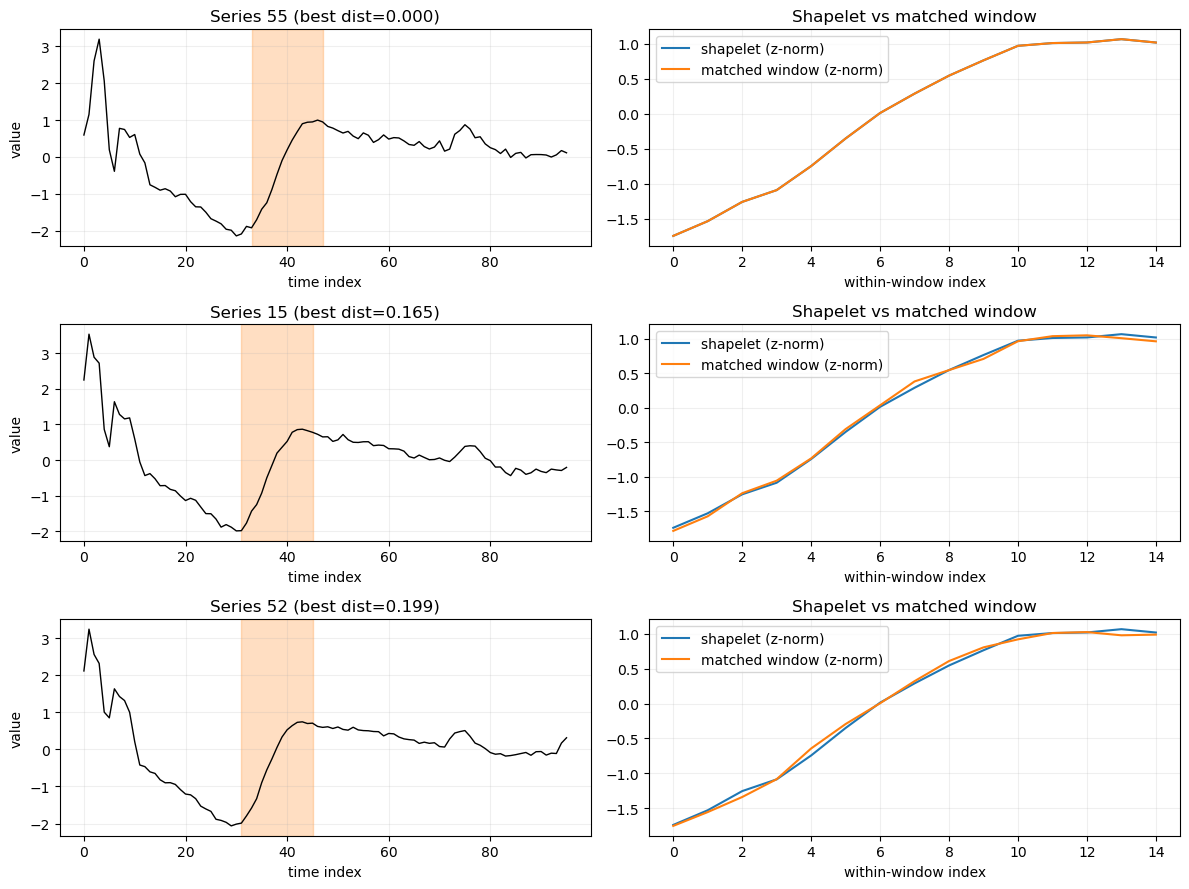

In [5]:
shapelet_id = 0
sh = shapelets[shapelet_id]
L = sh['length']

# Use the window-z-normalized distances for the demo
dists = D_winznorm[:, shapelet_id]
order = np.argsort(dists)

top_k = 3
print(f'Shapelet {shapelet_id}: length={L}, extracted from row={sh["source_row"]}, start={sh["start"]}')
print('Top matches (series index -> distance -> best window start):')
for rank in range(top_k):
    i = int(order[rank])
    pos = int(best_pos_winznorm[i, shapelet_id])
    print(f'  {i} -> {dists[i]:.4f} -> start={pos}')

fig, axes = plt.subplots(top_k, 2, figsize=(12, 3 * top_k))
if top_k == 1:
    axes = np.array([axes])

for rank in range(top_k):
    i = int(order[rank])
    pos = int(best_pos_winznorm[i, shapelet_id])
    ts = X[i]

    ax_ts = axes[rank, 0]
    ax_ts.plot(ts, color='black', linewidth=1)
    ax_ts.axvspan(pos, pos + L - 1, color='tab:orange', alpha=0.25)
    ax_ts.set_title(f'Series {i} (best dist={dists[i]:.3f})')
    ax_ts.set_xlabel('time index')
    ax_ts.set_ylabel('value')
    ax_ts.grid(alpha=0.2)

    ax_sh = axes[rank, 1]
    ax_sh.plot(z_norm_1d(sh['values']), label='shapelet (z-norm)', color='tab:blue')
    window = ts[pos:pos + L]
    ax_sh.plot(z_norm_1d(window), label='matched window (z-norm)', color='tab:orange')
    ax_sh.set_title('Shapelet vs matched window')
    ax_sh.set_xlabel('within-window index')
    ax_sh.grid(alpha=0.2)
    ax_sh.legend()

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8560\1237984970.py:17: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances.append(np.abs(np.cross(line, p - p1)) / line_norm)


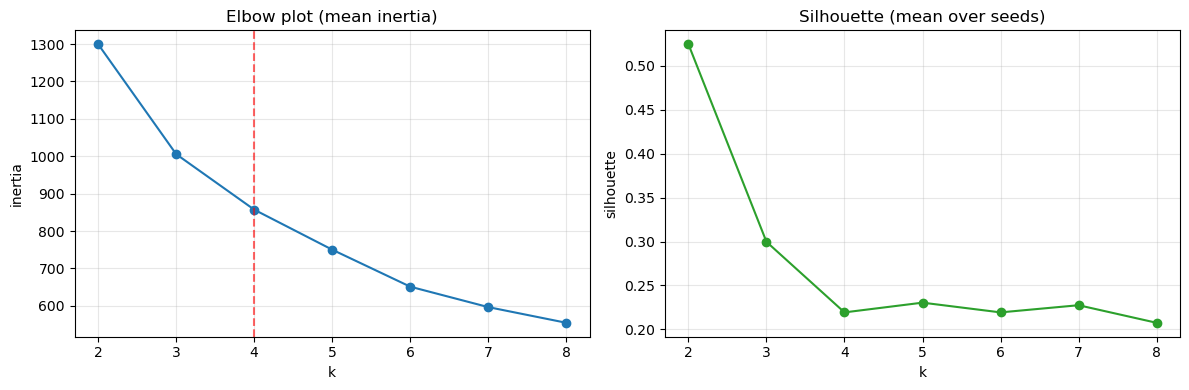

,k,silhouette,silhouette_std,calinski_harabasz,davies_bouldin,stability_ari,stability_ari_std,elbow_k,rank_sum,rank_sum_penalized
0,2,0.524612,0.002742,106.763460,1.091135,0.988193,0.014461,4,5.0,5.00
1,3,0.299679,0.000000,97.420307,1.250792,1.000000,0.000000,4,10.0,10.15
2,5,0.230416,0.001623,81.219048,1.131341,0.840890,0.144072,4,15.0,15.45
3,4,0.219336,0.001472,87.100501,1.338353,0.924706,0.059141,4,17.5,17.80
4,6,0.219331,0.002500,80.350452,1.152843,0.863983,0.066941,4,18.0,18.60
5,7,0.227496,0.003361,75.648976,1.224492,0.844219,0.103015,4,19.0,19.75
6,8,0.207483,0.012965,71.449844,1.279908,0.661466,0.141173,4,27.0,27.90


Best k (unsupervised, shapelet features): 2


In [6]:
# Unsupervised k selection on shapelet features
k_values = list(range(2, 9))
seed_list = [0, 1, 2, 3, 4]

def elbow_k_from_line(k_list, inertia_list):
    x = np.asarray(k_list, dtype=float)
    y = np.asarray(inertia_list, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line = p2 - p1
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        return int(k_list[0])
    distances = []
    for i in range(len(x)):
        p = np.array([x[i], y[i]])
        distances.append(np.abs(np.cross(line, p - p1)) / line_norm)
    return int(k_list[int(np.argmax(distances))])

rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

inertias = []
silhouettes = []
silhouettes_std = []
ch_scores = []
ch_scores_std = []
db_scores = []
db_scores_std = []
stabilities = []
stabilities_std = []

for k in k_values:
    labels_by_seed = []
    inertias_by_seed = []
    sil_by_seed = []
    ch_by_seed = []
    db_by_seed = []

    for seed in seed_list:
        km = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = km.fit_predict(X_shapelet)
        labels_by_seed.append(labels)
        inertias_by_seed.append(float(km.inertia_))
        sil_by_seed.append(float(silhouette_score(X_shapelet, labels)))
        ch_by_seed.append(float(calinski_harabasz_score(X_shapelet, labels)))
        db_by_seed.append(float(davies_bouldin_score(X_shapelet, labels)))

    inertias.append(float(np.mean(inertias_by_seed)))
    silhouettes.append(float(np.mean(sil_by_seed)))
    silhouettes_std.append(float(np.std(sil_by_seed, ddof=0)))
    ch_scores.append(float(np.mean(ch_by_seed)))
    ch_scores_std.append(float(np.std(ch_by_seed, ddof=0)))
    db_scores.append(float(np.mean(db_by_seed)))
    db_scores_std.append(float(np.std(db_by_seed, ddof=0)))

    pairwise_ari = []
    for i in range(len(labels_by_seed)):
        for j in range(i + 1, len(labels_by_seed)):
            pairwise_ari.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))
    stabilities.append(float(np.mean(pairwise_ari)))
    stabilities_std.append(float(np.std(pairwise_ari, ddof=0)))

elbow_k = elbow_k_from_line(k_values, inertias)

for i, k in enumerate(k_values):
    rows.append({
        'k': k,
        'inertia': inertias[i],
        'silhouette': silhouettes[i],
        'silhouette_std': silhouettes_std[i],
        'calinski_harabasz': ch_scores[i],
        'calinski_harabasz_std': ch_scores_std[i],
        'davies_bouldin': db_scores[i],
        'davies_bouldin_std': db_scores_std[i],
        'stability_ari': stabilities[i],
        'stability_ari_std': stabilities_std[i],
        'elbow_k': elbow_k,
        'elbow_match': int(k == elbow_k),
    })

axes[0].plot(k_values, inertias, marker='o')
axes[0].axvline(elbow_k, color='r', linestyle='--', alpha=0.6)
axes[0].set_title('Elbow plot (mean inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, silhouettes, marker='o', color='tab:green')
axes[1].set_title('Silhouette (mean over seeds)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

selection_df = pd.DataFrame(rows)

for metric in ['silhouette', 'calinski_harabasz', 'stability_ari']:
    selection_df[f'rank_{metric}'] = selection_df[metric].rank(method='dense', ascending=False)
selection_df['rank_davies_bouldin'] = selection_df['davies_bouldin'].rank(method='dense', ascending=True)

selection_df['rank_sum'] = (
    selection_df['rank_silhouette']
    + selection_df['rank_calinski_harabasz']
    + selection_df['rank_davies_bouldin']
    + selection_df['rank_stability_ari']
    - 0.5 * selection_df['elbow_match']
    )

min_k = min(k_values)
k_penalty = 0.15
selection_df['rank_sum_penalized'] = selection_df['rank_sum'] + k_penalty * (selection_df['k'] - min_k)

selection_df = selection_df.sort_values(
    ['rank_sum_penalized', 'silhouette', 'stability_ari', 'k'],
    ascending=[True, False, False, True],
).reset_index(drop=True)

display(selection_df[[
    'k',
    'silhouette',
    'silhouette_std',
    'calinski_harabasz',
    'davies_bouldin',
    'stability_ari',
    'stability_ari_std',
    'elbow_k',
    'rank_sum',
    'rank_sum_penalized',
]])

best_k_shapelet = int(selection_df.iloc[0]['k'])

print('Best k (unsupervised, shapelet features):', best_k_shapelet)

In [7]:
# Fit KMeans using best_k on shapelet features
model = KMeans(n_clusters=best_k_shapelet, random_state=42, n_init=50)
labels = model.fit_predict(X_shapelet)

summary_data = {
    'k': int(best_k_shapelet),
    'inertia': float(model.inertia_),
    'silhouette': float(silhouette_score(X_shapelet, labels)),
    'calinski_harabasz': float(calinski_harabasz_score(X_shapelet, labels)),
    'davies_bouldin': float(davies_bouldin_score(X_shapelet, labels)),
}

fit_summary_df = pd.DataFrame([summary_data])
display(fit_summary_df)

print('Final model: k=%d (shapelet features)' % best_k_shapelet)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,1299.439193,0.525983,106.746849,1.089544


Final model: k=2 (shapelet features)


In [8]:
# Post-hoc label benchmark (uses y_true only for evaluation)
def majority_label_mapping(y_ref, clusters):
    mapping = {}
    for c in np.unique(clusters):
        mapping[c] = pd.Series(y_ref[clusters == c]).mode().iloc[0]
    return mapping

def mapped_predictions(clusters, mapping):
    return np.array([mapping[c] for c in clusters])

map_eval = majority_label_mapping(y_true, labels)
pred_eval = mapped_predictions(labels, map_eval)

benchmark_data = {
    'k': int(best_k_shapelet),
    'mapped_accuracy': float(accuracy_score(y_true, pred_eval)),
    'ari': float(adjusted_rand_score(y_true, labels)),
    'nmi': float(normalized_mutual_info_score(y_true, labels)),
    'silhouette': float(silhouette_score(X_shapelet, labels)),
    'clusters': int(len(np.unique(labels))),
    'classes': int(len(np.unique(y_true))),
}

benchmark_df = pd.DataFrame([benchmark_data])

display(benchmark_df)

print('Note: the table above uses ground-truth labels for evaluation only (not for selecting k).')
print('Unsupervised k selection:', {'k': best_k_shapelet})

,k,mapped_accuracy,ari,nmi,silhouette,clusters,classes
0,2,0.675,0.061706,0.024598,0.525983,2,2


Note: the table above uses ground-truth labels for evaluation only (not for selecting k).
Unsupervised k selection: {'k': 2}


In [9]:
# Compare clusters vs labels
comparison = pd.DataFrame({'true_label': y_true, 'cluster': labels})
crosstab = pd.crosstab(comparison['true_label'], comparison['cluster'])

print('Cluster-Label Crosstab:')
display(crosstab)

majority_mapping = {}
for c in sorted(comparison['cluster'].unique()):
    mode_label = comparison.loc[comparison['cluster'] == c, 'true_label'].mode().iloc[0]
    majority_mapping[c] = mode_label

predicted_by_cluster = np.array([majority_mapping[c] for c in comparison['cluster']])
agreement = (predicted_by_cluster == y_true).mean()
ari_score = adjusted_rand_score(y_true, labels)
nmi_score = normalized_mutual_info_score(y_true, labels)

print('\nCluster -> label mapping:', majority_mapping)
print('Agreement with true labels (majority-mapped):', round(float(agreement), 4))
print('Adjusted Rand Index:', round(float(ari_score), 4))
print('Normalized Mutual Information:', round(float(nmi_score), 4))

Cluster-Label Crosstab:


cluster,0,1
true_label,,
-1,13,54
1,11,122



Cluster -> label mapping: {np.int32(0): np.int64(-1), np.int32(1): np.int64(1)}
Agreement with true labels (majority-mapped): 0.675
Adjusted Rand Index: 0.0617
Normalized Mutual Information: 0.0246


## Functional boxplot (pattern summary)

This summarizes a set of curves by:
- a **median curve** (deepest)
- a **central envelope** (deepest 50%)
- optional **outliers** (curves leaving the inflated envelope)

We compute it on the **original ECG curves `X`**, but grouped by the clusters learned from shapelet features.

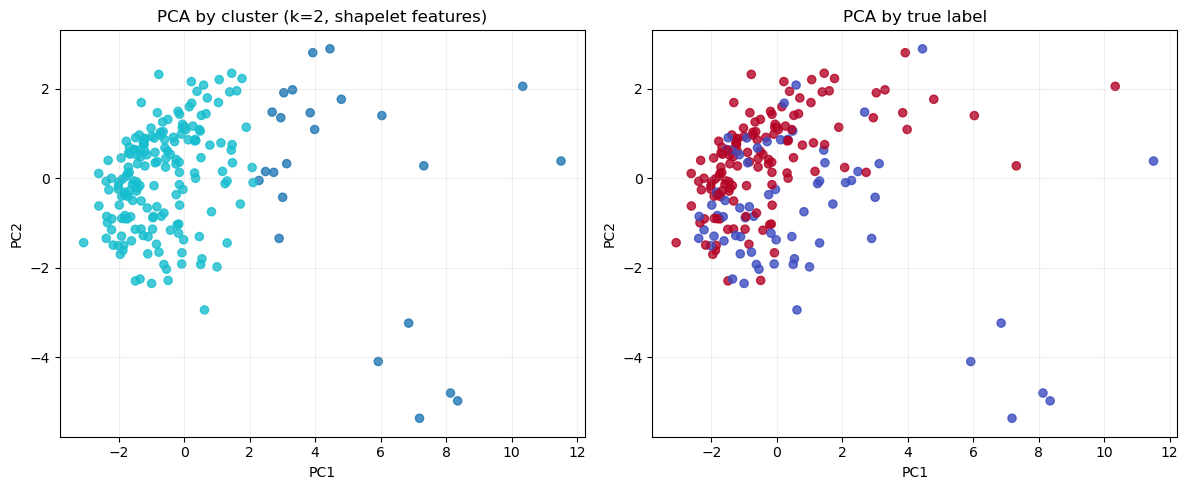

In [10]:
# 2D projection for visual inspection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_shapelet)

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=35, cmap='tab10', alpha=0.8)
axes[0].set_title('PCA by cluster (k=%d, shapelet features)' % best_k_shapelet)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.2)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, s=35, cmap='coolwarm', alpha=0.8)
axes[1].set_title('PCA by true label')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Shapelet patterns per cluster

In shapelet space, each feature is a **distance to one shapelet** (smaller = shapelet appears somewhere). Below: shapelets with the **smallest average distance** inside each cluster.

Surrogate tree train fidelity: 0.955
Surrogate tree CV fidelity: 0.93

Surrogate rules:

|--- s_1 <= 0.86
|   |--- s_5 <= 0.88
|   |   |--- s_9 <= 1.27
|   |   |   |--- class: 1
|   |   |--- s_9 >  1.27
|   |   |   |--- class: 1
|   |--- s_5 >  0.88
|   |   |--- class: 1
|--- s_1 >  0.86
|   |--- s_2 <= 0.52
|   |   |--- class: 0
|   |--- s_2 >  0.52
|   |   |--- class: 0



,feature,importance
1,s_1,0.825045
5,s_5,0.122187
2,s_2,0.045067
9,s_9,0.007701
0,s_0,0.000000
3,s_3,0.000000
4,s_4,0.000000
6,s_6,0.000000
7,s_7,0.000000
8,s_8,0.000000


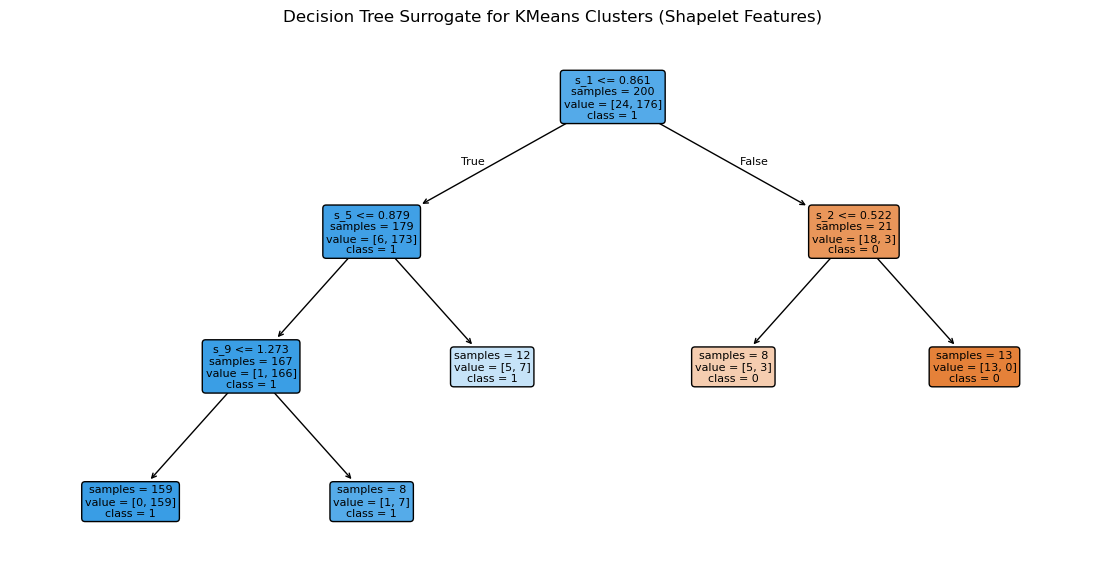

In [11]:
# Train surrogate decision tree for explainability
feature_names = [f's_{i}' for i in range(X_shapelet.shape[1])]

surrogate = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=42)
surrogate.fit(X_shapelet, labels)

surrogate_pred = surrogate.predict(X_shapelet)
train_fidelity = accuracy_score(labels, surrogate_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_fidelity = cross_val_score(
    surrogate, X_shapelet, labels, cv=cv, scoring='accuracy'
).mean()

print('Surrogate tree train fidelity:', round(float(train_fidelity), 4))
print('Surrogate tree CV fidelity:', round(float(cv_fidelity), 4))

rules = export_text(surrogate, feature_names=feature_names)
print('\nSurrogate rules:\n')
print(rules)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': surrogate.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(14, 7))
plot_tree(
    surrogate,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(np.unique(labels))],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
)
plt.title('Decision Tree Surrogate for KMeans Clusters (Shapelet Features)')
plt.show()

Top SHAP features (shapelet-based):


,feature,mean_abs_shap
0,s_1,0.136016
1,s_5,0.053197
2,s_2,0.020278
3,s_9,0.011989
4,s_0,0.000000
5,s_3,0.000000
6,s_4,0.000000
7,s_6,0.000000
8,s_7,0.000000
9,s_8,0.000000


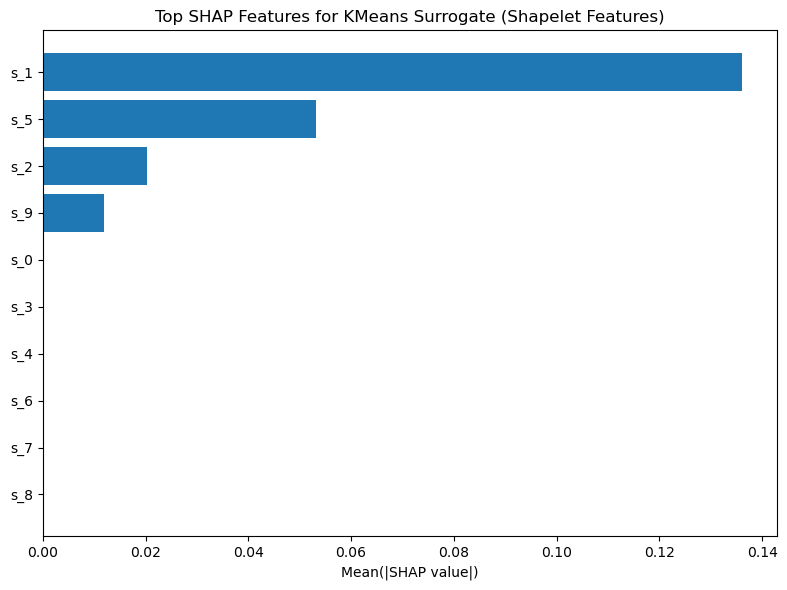

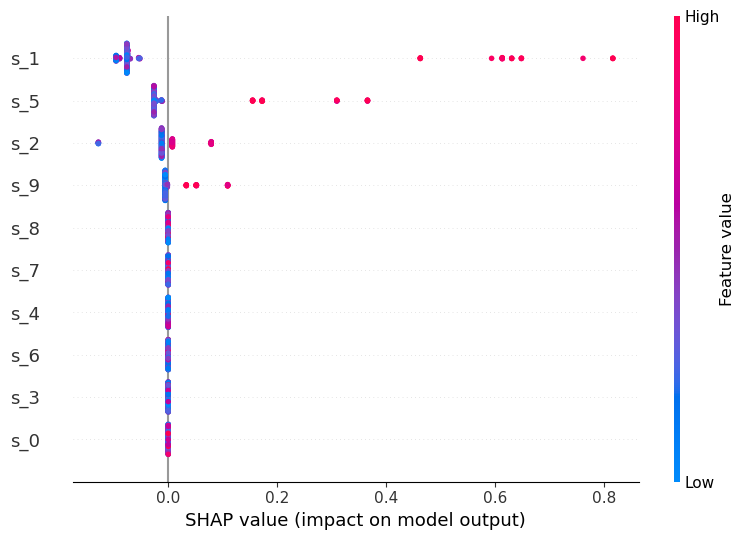

In [12]:
# SHAP feature attributions for surrogate tree
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print('SHAP is not installed. Install with: pip install shap')

if shap_available:
    explainer = shap.TreeExplainer(surrogate)
    raw_shap = explainer.shap_values(X_shapelet)

    # Aggregate class-wise outputs for multiclass trees
    if isinstance(raw_shap, list):
        shap_abs_mean = np.mean(
            np.stack([np.abs(class_values).mean(axis=0) for class_values in raw_shap], axis=0),
            axis=0,
        )
        shap_for_beeswarm = raw_shap[0]
    elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
        shap_abs_mean = np.abs(raw_shap).mean(axis=(0, 2))
        shap_for_beeswarm = raw_shap[:, :, 0]
    else:
        shap_abs_mean = np.abs(raw_shap).mean(axis=0)
        shap_for_beeswarm = raw_shap

    shap_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': shap_abs_mean,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    print('Top SHAP features (shapelet-based):')
    display(shap_importance_df.head(15))

    top_n = 15
    top_df = shap_importance_df.head(top_n).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top_df['feature'], top_df['mean_abs_shap'])
    plt.title('Top SHAP Features for KMeans Surrogate (Shapelet Features)')
    plt.xlabel('Mean(|SHAP value|)')
    plt.tight_layout()
    plt.show()

    # SHAP beeswarm plot
    try:
        shap.summary_plot(
            shap_for_beeswarm,
            pd.DataFrame(X_shapelet, columns=feature_names),
            max_display=15,
            show=True,
        )
    except Exception as ex:
        print('Could not render SHAP beeswarm summary:', ex)

In [15]:
def _leaf_constraints(tree_):
    n_features = tree_.n_features
    constraints = {}

    def walk(node_id, low, high):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        if left_id == right_id:
            constraints[node_id] = (low.copy(), high.copy())
            return

        feat = tree_.feature[node_id]
        thr = tree_.threshold[node_id]

        high_left = high.copy()
        high_left[feat] = min(high_left[feat], thr)
        walk(left_id, low.copy(), high_left)

        low_right = low.copy()
        low_right[feat] = max(low_right[feat], np.nextafter(thr, np.inf))
        walk(right_id, low_right, high.copy())

    walk(
        0,
        np.full(n_features, -np.inf, dtype=float),
        np.full(n_features, np.inf, dtype=float),
    )
    return constraints


def _as_scalar_label(value):
    try:
        return int(value)
    except Exception:
        return value


def _best_abductive_edit(surrogate, x_row, feature_names, max_display_features=6):
    tree_ = surrogate.tree_
    leaf_rules = _leaf_constraints(tree_)
    classes = surrogate.classes_

    current_label = surrogate.predict(x_row.reshape(1, -1))[0]
    current_label_scalar = _as_scalar_label(current_label)

    best = None
    for leaf_id, (low, high) in leaf_rules.items():
        target_idx = int(np.argmax(tree_.value[leaf_id][0]))
        target_label = classes[target_idx]
        target_label_scalar = _as_scalar_label(target_label)

        if target_label_scalar == current_label_scalar:
            continue

        x_new = x_row.astype(float).copy()
        edits = []
        for feat_idx in range(x_new.shape[0]):
            old_val = float(x_new[feat_idx])
            new_val = old_val

            if old_val < low[feat_idx]:
                new_val = float(low[feat_idx])
            elif old_val > high[feat_idx]:
                new_val = float(high[feat_idx])

            if new_val != old_val:
                x_new[feat_idx] = new_val
                edits.append((feat_idx, old_val, new_val, abs(new_val - old_val)))

        predicted_new = surrogate.predict(x_new.reshape(1, -1))[0]
        predicted_new_scalar = _as_scalar_label(predicted_new)
        if predicted_new_scalar != target_label_scalar:
            continue

        n_changed = len(edits)
        total_shift = float(sum(item[3] for item in edits))

        changed_features = [feature_names[item[0]] for item in edits]
        edits_preview = '; '.join(
            [
                f"{feature_names[item[0]]}: {item[1]:.3f} -> {item[2]:.3f}"
                for item in edits[:max_display_features]
            ]
        )

        candidate = {
            'original_cluster': current_label_scalar,
            'target_cluster': target_label_scalar,
            'n_features_changed': n_changed,
            'total_abs_shift': total_shift,
            'changed_features': ', '.join(changed_features),
            'suggested_edits': edits_preview,
        }

        if best is None:
            best = candidate
        else:
            current_score = (candidate['n_features_changed'], candidate['total_abs_shift'])
            best_score = (best['n_features_changed'], best['total_abs_shift'])
            if current_score < best_score:
                best = candidate

    return best


sample_count = min(12, X_shapelet.shape[0])
sample_indices = np.unique(np.linspace(0, X_shapelet.shape[0] - 1, num=sample_count, dtype=int))

rows = []
for idx in sample_indices:
    best_edit = _best_abductive_edit(surrogate, X_shapelet[idx], feature_names)
    if best_edit is None:
        continue
    rows.append({'sample_idx': int(idx), **best_edit})

abductive_df = pd.DataFrame(rows)
print('Shapelet-feature abductive explanations from surrogate rules')
if abductive_df.empty:
    print('No abductive edits found for the sampled points.')
else:
    display(abductive_df.head(12))
    summary = abductive_df[['n_features_changed', 'total_abs_shift']].agg(['mean', 'min', 'max'])
    print('Abductive summary stats:')
    display(summary)

Shapelet-feature abductive explanations from surrogate rules


,sample_idx,original_cluster,target_cluster,n_features_changed,total_abs_shift,changed_features,suggested_edits
0,162,0,1,1,0.022163,s_1,s_1: 0.883 -> 0.861


Abductive summary stats:


,n_features_changed,total_abs_shift
mean,1.0,0.022163
min,1.0,0.022163
max,1.0,0.022163


## SHAP explanation for shapelets (with aggregate shapelet statistics)

This section links SHAP-important shapelet features to each shapelet's aggregate statistics (`mean`, `max`, `variance`) so the explanation is easier to interpret later.

In [9]:
if not shap_available:
    print('SHAP not available; skipping enriched SHAP-shapelet summary.')
elif not shap_importance_by_view:
    print('No SHAP outputs captured yet. Run the SHAP cell above first.')
else:
    shapelet_stats = shapelet_meta[[
        'shapelet_id',
        'length',
        'shapelet_mean',
        'shapelet_max',
        'shapelet_variance',
    ]].copy()

    shap_shapelet_enriched_by_view = {}
    for view_name, shap_df in shap_importance_by_view.items():
        enriched_df = shap_df.copy()
        enriched_df['shapelet_id'] = pd.to_numeric(
            enriched_df['feature'].str.extract(r'shapelet_(\d+)_')[0],
            errors='coerce',
        ).astype('Int64')
        enriched_df = enriched_df.merge(shapelet_stats, on='shapelet_id', how='left')
        shap_shapelet_enriched_by_view[view_name] = enriched_df

        print(f'\nView: {view_name} (SHAP + shapelet aggregate stats)')
        display(enriched_df.head(15))


View: shapelet_dist_winznorm_std (SHAP + shapelet aggregate stats)


,feature,mean_abs_shap,shapelet_id,length,shapelet_mean,shapelet_max,shapelet_variance
0,shapelet_10_L20,0.168308,10,20,-0.579887,1.080625,0.921222
1,shapelet_9_L25,0.093117,9,25,-1.122047,0.284496,0.539577
2,shapelet_24_L20,0.018301,24,20,0.484427,1.011705,0.045951
3,shapelet_1_L20,0.000000,1,20,0.016428,0.530912,0.033924
4,shapelet_4_L25,0.000000,4,25,0.579688,0.720724,0.019227
5,shapelet_5_L25,0.000000,5,25,-0.759957,-0.011556,0.199608
6,shapelet_2_L15,0.000000,2,15,-0.785997,0.051487,0.133827
7,shapelet_3_L15,0.000000,3,15,-0.028710,0.289316,0.016122
8,shapelet_0_L15,0.000000,0,15,0.450190,0.866726,0.030739
9,shapelet_8_L25,0.000000,8,25,0.362983,0.864146,0.347458



View: shapelet_dist_noznorm_std (SHAP + shapelet aggregate stats)


,feature,mean_abs_shap,shapelet_id,length,shapelet_mean,shapelet_max,shapelet_variance
0,shapelet_6_L25,0.234795,6,25,-0.990527,0.243796,0.419893
1,shapelet_23_L20,0.046807,23,20,-0.505116,0.388191,0.243977
2,shapelet_9_L25,0.043409,9,25,-1.122047,0.284496,0.539577
3,shapelet_24_L20,0.027380,24,20,0.484427,1.011705,0.045951
4,shapelet_3_L15,0.008622,3,15,-0.028710,0.289316,0.016122
5,shapelet_4_L25,0.000000,4,25,0.579688,0.720724,0.019227
6,shapelet_0_L15,0.000000,0,15,0.450190,0.866726,0.030739
7,shapelet_2_L15,0.000000,2,15,-0.785997,0.051487,0.133827
8,shapelet_1_L20,0.000000,1,20,0.016428,0.530912,0.033924
9,shapelet_8_L25,0.000000,8,25,0.362983,0.864146,0.347458


## Abductive explanations for shapelet-based clustering

Abductive explanations here are generated from the surrogate decision tree: for each sample, we find a nearby rule-consistent edit that changes the predicted cluster with minimal feature edits.

In [10]:
def _leaf_constraints(tree_):
    n_features = tree_.n_features
    constraints = {}

    def walk(node_id, low, high):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        if left_id == right_id:
            constraints[node_id] = (low.copy(), high.copy())
            return

        feat = tree_.feature[node_id]
        thr = tree_.threshold[node_id]

        high_left = high.copy()
        high_left[feat] = min(high_left[feat], thr)
        walk(left_id, low.copy(), high_left)

        low_right = low.copy()
        low_right[feat] = max(low_right[feat], np.nextafter(thr, np.inf))
        walk(right_id, low_right, high.copy())

    walk(
        0,
        np.full(n_features, -np.inf, dtype=float),
        np.full(n_features, np.inf, dtype=float),
    )
    return constraints


def _as_scalar_label(value):
    try:
        return int(value)
    except Exception:
        return value


def _best_abductive_edit(surrogate, x_row, feature_names, max_display_features=6):
    tree_ = surrogate.tree_
    leaf_rules = _leaf_constraints(tree_)
    classes = surrogate.classes_

    current_label = surrogate.predict(x_row.reshape(1, -1))[0]
    current_label_scalar = _as_scalar_label(current_label)

    best = None
    for leaf_id, (low, high) in leaf_rules.items():
        target_idx = int(np.argmax(tree_.value[leaf_id][0]))
        target_label = classes[target_idx]
        target_label_scalar = _as_scalar_label(target_label)

        if target_label_scalar == current_label_scalar:
            continue

        x_new = x_row.astype(float).copy()
        edits = []
        for feat_idx in range(x_new.shape[0]):
            old_val = float(x_new[feat_idx])
            new_val = old_val

            if old_val < low[feat_idx]:
                new_val = float(low[feat_idx])
            elif old_val > high[feat_idx]:
                new_val = float(high[feat_idx])

            if new_val != old_val:
                x_new[feat_idx] = new_val
                edits.append((feat_idx, old_val, new_val, abs(new_val - old_val)))

        predicted_new = surrogate.predict(x_new.reshape(1, -1))[0]
        predicted_new_scalar = _as_scalar_label(predicted_new)
        if predicted_new_scalar != target_label_scalar:
            continue

        n_changed = len(edits)
        total_shift = float(sum(item[3] for item in edits))

        changed_features = [feature_names[item[0]] for item in edits]
        edits_preview = '; '.join(
            [
                f"{feature_names[item[0]]}: {item[1]:.3f} -> {item[2]:.3f}"
                for item in edits[:max_display_features]
            ]
        )

        candidate = {
            'original_cluster': current_label_scalar,
            'target_cluster': target_label_scalar,
            'n_features_changed': n_changed,
            'total_abs_shift': total_shift,
            'changed_features': ', '.join(changed_features),
            'suggested_edits': edits_preview,
        }

        if best is None:
            best = candidate
        else:
            current_score = (candidate['n_features_changed'], candidate['total_abs_shift'])
            best_score = (best['n_features_changed'], best['total_abs_shift'])
            if current_score < best_score:
                best = candidate

    return best


abductive_by_view = {}
for view_name, payload in surrogates_by_view.items():
    surrogate = payload['surrogate']
    X_used = np.asarray(payload['X_used'])
    feature_names = payload['feature_names']

    sample_count = min(12, X_used.shape[0])
    sample_indices = np.unique(np.linspace(0, X_used.shape[0] - 1, num=sample_count, dtype=int))

    rows = []
    for idx in sample_indices:
        best_edit = _best_abductive_edit(surrogate, X_used[idx], feature_names)
        if best_edit is None:
            continue
        rows.append({'sample_idx': int(idx), **best_edit})

    abductive_df = pd.DataFrame(rows)
    abductive_by_view[view_name] = abductive_df

    print(f'\nView: {view_name} (abductive explanations from surrogate rules)')
    if abductive_df.empty:
        print('No abductive edits found for the sampled points.')
    else:
        display(abductive_df.head(12))
        summary = abductive_df[['n_features_changed', 'total_abs_shift']].agg(['mean', 'min', 'max'])
        print('Abductive summary stats:')
        display(summary)


View: shapelet_dist_winznorm_std (abductive explanations from surrogate rules)


,sample_idx,original_cluster,target_cluster,n_features_changed,total_abs_shift,changed_features,suggested_edits
0,0,1,0,1,0.856906,shapelet_9_L25,shapelet_9_L25: 0.151 -> 1.008
1,18,1,0,1,0.638265,shapelet_9_L25,shapelet_9_L25: 0.370 -> 1.008
2,36,1,0,1,0.759944,shapelet_9_L25,shapelet_9_L25: 0.248 -> 1.008
3,54,1,0,1,1.008735,shapelet_9_L25,shapelet_9_L25: -0.001 -> 1.008
4,72,1,0,1,0.102109,shapelet_9_L25,shapelet_9_L25: 0.906 -> 1.008
5,90,1,0,1,1.154663,shapelet_9_L25,shapelet_9_L25: -0.147 -> 1.008
6,108,1,0,1,1.631513,shapelet_9_L25,shapelet_9_L25: -0.624 -> 1.008
7,126,1,0,1,1.837832,shapelet_9_L25,shapelet_9_L25: -0.830 -> 1.008
8,144,1,0,1,0.941446,shapelet_9_L25,shapelet_9_L25: 0.066 -> 1.008
9,162,0,1,1,0.532186,shapelet_9_L25,shapelet_9_L25: 1.168 -> 0.636


Abductive summary stats:


,n_features_changed,total_abs_shift
mean,1.0,1.088346
min,1.0,0.102109
max,1.0,1.887898



View: shapelet_dist_noznorm_std (abductive explanations from surrogate rules)


,sample_idx,original_cluster,target_cluster,n_features_changed,total_abs_shift,changed_features,suggested_edits
0,0,1,0,1,1.648158,shapelet_23_L20,shapelet_23_L20: -1.190 -> 0.458
1,36,0,2,1,2.292313,shapelet_9_L25,shapelet_9_L25: -0.498 -> 1.794
2,54,0,1,1,1.132137,shapelet_6_L25,shapelet_6_L25: 0.800 -> -0.332
3,72,1,0,1,1.647305,shapelet_23_L20,shapelet_23_L20: -1.189 -> 0.458
4,90,1,0,1,1.588991,shapelet_23_L20,shapelet_23_L20: -1.131 -> 0.458
5,108,0,2,1,1.881495,shapelet_9_L25,shapelet_9_L25: -0.087 -> 1.794
6,126,1,0,1,1.821282,shapelet_23_L20,shapelet_23_L20: -1.363 -> 0.458
7,144,0,1,1,0.983827,shapelet_6_L25,shapelet_6_L25: 0.652 -> -0.332
8,162,0,2,1,0.789604,shapelet_9_L25,shapelet_9_L25: 1.005 -> 1.794
9,180,0,1,1,0.582868,shapelet_6_L25,shapelet_6_L25: 0.251 -> -0.332


Abductive summary stats:


,n_features_changed,total_abs_shift
mean,1.0,1.464245
min,1.0,0.582868
max,1.0,2.292313
